In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("data/hospital_readmissions.csv")

In [3]:
df.head()

,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted
0,[70-80),8,72,1,18,2,0,0,Missing,Circulatory,Respiratory,Other,no,no,no,yes,no
1,[70-80),3,34,2,13,0,0,0,Other,Other,Other,Other,no,no,no,yes,no
2,[50-60),5,45,0,18,0,0,0,Missing,Circulatory,Circulatory,Circulatory,no,no,yes,yes,yes
3,[70-80),2,36,0,12,1,0,0,Missing,Circulatory,Other,Diabetes,no,no,yes,yes,yes
4,[60-70),1,42,0,7,0,0,0,InternalMedicine,Other,Circulatory,Respiratory,no,no,no,yes,no


In [4]:
df.shape

(25000, 17)

In [5]:
df.columns

Index(['age', 'time_in_hospital', 'n_lab_procedures', 'n_procedures',
       'n_medications', 'n_outpatient', 'n_inpatient', 'n_emergency',
       'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'glucose_test',
       'A1Ctest', 'change', 'diabetes_med', 'readmitted'],
      dtype='object')

In [6]:
df.dtypes

age                  object
time_in_hospital      int64
n_lab_procedures      int64
n_procedures          int64
n_medications         int64
n_outpatient          int64
n_inpatient           int64
n_emergency           int64
medical_specialty    object
diag_1               object
diag_2               object
diag_3               object
glucose_test         object
A1Ctest              object
change               object
diabetes_med         object
readmitted           object
dtype: object

In [7]:
df.isnull().sum()

age                  0
time_in_hospital     0
n_lab_procedures     0
n_procedures         0
n_medications        0
n_outpatient         0
n_inpatient          0
n_emergency          0
medical_specialty    0
diag_1               0
diag_2               0
diag_3               0
glucose_test         0
A1Ctest              0
change               0
diabetes_med         0
readmitted           0
dtype: int64

In [8]:
df["readmitted"].value_counts()

readmitted
no     13246
yes    11754
Name: count, dtype: int64

# Hospital Readmission Analysis

## Project Objective

This project investigates factors associated with hospital readmission using patient and hospital data.

## Initial Hypotheses

1. I hypothesise that older patients may have a higher rate of hospital readmission.

2. I hypothesise that patients with longer hospital stays may have a higher rate of readmission.

3. I hypothesise that patients with a greater number of previous hospital encounters may have a higher rate of readmission.

# Data Cleaning

In [9]:
df.isnull().sum()

age                  0
time_in_hospital     0
n_lab_procedures     0
n_procedures         0
n_medications        0
n_outpatient         0
n_inpatient          0
n_emergency          0
medical_specialty    0
diag_1               0
diag_2               0
diag_3               0
glucose_test         0
A1Ctest              0
change               0
diabetes_med         0
readmitted           0
dtype: int64

In [10]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["readmitted"].value_counts()

readmitted
no     13246
yes    11754
Name: count, dtype: int64

In [13]:
df["change"].value_counts()

change
no     13497
yes    11503
Name: count, dtype: int64

In [14]:
df["diabetes_med"].value_counts()

diabetes_med
yes    19228
no      5772
Name: count, dtype: int64

In [15]:
df["glucose_test"].value_counts()

glucose_test
no        23625
normal      689
high        686
Name: count, dtype: int64

In [16]:
df["A1Ctest"].value_counts()

A1Ctest
no        20938
high       2827
normal     1235
Name: count, dtype: int64

In [17]:
df["medical_specialty"].value_counts()

medical_specialty
Missing                   12382
InternalMedicine           3565
Other                      2664
Emergency/Trauma           1885
Family/GeneralPractice     1882
Cardiology                 1409
Surgery                    1213
Name: count, dtype: int64

In [18]:
df["medical_specialty"].value_counts(normalize=True) * 100

medical_specialty
Missing                   49.528
InternalMedicine          14.260
Other                     10.656
Emergency/Trauma           7.540
Family/GeneralPractice     7.528
Cardiology                 5.636
Surgery                    4.852
Name: proportion, dtype: float64

In [19]:
df.describe()

,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency
count,25000.00000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,4.45332,43.24076,1.352360,16.252400,0.366400,0.615960,0.186600
std,3.00147,19.81862,1.715179,8.060532,1.195478,1.177951,0.885873
min,1.00000,1.00000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,2.00000,31.00000,0.000000,11.000000,0.000000,0.000000,0.000000
50%,4.00000,44.00000,1.000000,15.000000,0.000000,0.000000,0.000000
75%,6.00000,57.00000,2.000000,20.000000,0.000000,1.000000,0.000000
max,14.00000,113.00000,6.000000,79.000000,33.000000,15.000000,64.000000


In [20]:
count_columns = [
    "time_in_hospital",
    "n_lab_procedures",
    "n_procedures",
    "n_medications",
    "n_outpatient",
    "n_inpatient",
    "n_emergency"
]

(df[count_columns] < 0).sum()

time_in_hospital    0
n_lab_procedures    0
n_procedures        0
n_medications       0
n_outpatient        0
n_inpatient         0
n_emergency         0
dtype: int64

In [21]:
df.select_dtypes(include="object").nunique()

age                  6
medical_specialty    7
diag_1               8
diag_2               8
diag_3               8
glucose_test         3
A1Ctest              3
change               2
diabetes_med         2
readmitted           2
dtype: int64

In [22]:
df_clean = df.copy()

In [23]:
df_clean.shape

(25000, 17)

## Data Cleaning Decisions

The dataset was checked for missing values, duplicate records, invalid categorical values, and impossible negative values.

- No null (`NaN`) values were identified.
- No duplicate rows were identified.
- Categorical variables contained expected values.
- No negative values were found in the count-based numerical variables.
- The `medical_specialty` column contains `"Missing"` for approximately 49.5% of records. These records were retained rather than removed because deleting them would remove a substantial proportion of the dataset.
- No rows were removed during cleaning.

In [24]:
df_clean.to_csv("data/hospital_readmissions_clean.csv", index=False)

In [25]:
import os

os.listdir("data")

['.DS_Store',
 'hospital_readmissions_clean.csv',
 '.ipynb_checkpoints',
 'hospital_readmissions.csv']

# Exploratory Data Analysis

In this section, I will explore patterns in hospital readmissions and examine how patient characteristics and prior healthcare use may relate to readmission.

In [26]:
df_clean["readmitted"].value_counts()

readmitted
no     13246
yes    11754
Name: count, dtype: int64

In [27]:
df_clean["readmitted"].value_counts(normalize=True).mul(100).round(1)

readmitted
no     53.0
yes    47.0
Name: proportion, dtype: float64

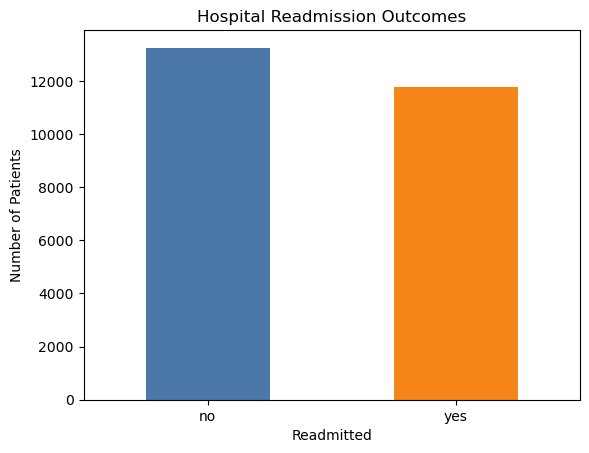

In [28]:
import matplotlib.pyplot as plt

df_clean["readmitted"].value_counts().plot(
    kind="bar",
    color=["#4C78A8", "#F58518"]
)

plt.title("Hospital Readmission Outcomes")
plt.xlabel("Readmitted")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()

In [29]:
age_readmission = pd.crosstab(
    df_clean["age"],
    df_clean["readmitted"],
    normalize="index"
) * 100

age_readmission.round(1)

readmitted,no,yes
age,,
[40-50),55.5,44.5
[50-60),55.8,44.2
[60-70),53.2,46.8
[70-80),51.2,48.8
[80-90),50.4,49.6
[90-100),57.9,42.1


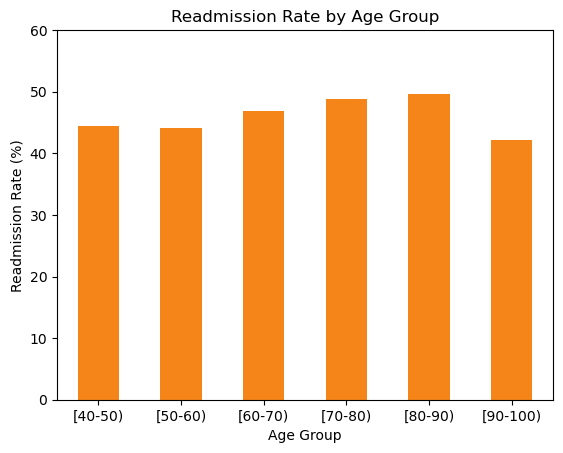

In [30]:
age_readmission["yes"].plot(
    kind="bar",
    color="#F58518"
)

plt.title("Readmission Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Readmission Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 60)
plt.show()

In [31]:
df_clean["age"].value_counts().sort_index()

age
[40-50)     2532
[50-60)     4452
[60-70)     5913
[70-80)     6837
[80-90)     4516
[90-100)     750
Name: count, dtype: int64

In [32]:
df_clean.groupby("readmitted")["time_in_hospital"].agg(
    ["count", "mean", "median"]
).round(1)

,count,mean,median
readmitted,,,
no,13246,4.3,4.0
yes,11754,4.6,4.0


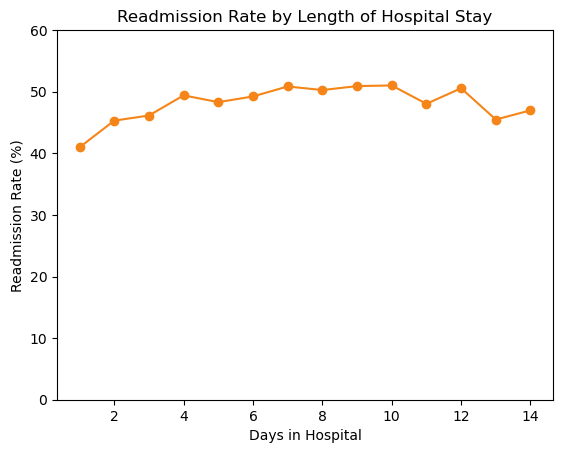

In [33]:
stay_readmission = pd.crosstab(
    df_clean["time_in_hospital"],
    df_clean["readmitted"],
    normalize="index"
) * 100

stay_readmission["yes"].plot(
    kind="line",
    marker="o",
    color="#F58518"
)

plt.title("Readmission Rate by Length of Hospital Stay")
plt.xlabel("Days in Hospital")
plt.ylabel("Readmission Rate (%)")
plt.ylim(0, 60)
plt.show()

In [34]:
inpatient_readmission = pd.crosstab(
    df_clean["n_inpatient"],
    df_clean["readmitted"],
    normalize="index"
) * 100

inpatient_readmission["yes"].round(1)

n_inpatient
0      39.9
1      54.7
2      64.6
3      70.3
4      76.3
5      81.0
6      90.4
7      85.1
8      92.3
9      85.0
10     91.7
11    100.0
12    100.0
13     50.0
14    100.0
15    100.0
Name: yes, dtype: float64

In [35]:
df_clean["n_inpatient"].value_counts().sort_index()

n_inpatient
0     16537
1      4926
2      1909
3       833
4       358
5       211
6       104
7        47
8        26
9        20
10       12
11        8
12        3
13        2
14        2
15        2
Name: count, dtype: int64

In [36]:
prior_inpatient_group = df_clean["n_inpatient"].apply(
    lambda visits: "One or more prior visits" if visits > 0 else "No prior visits"
)

prior_inpatient_summary = pd.crosstab(
    prior_inpatient_group,
    df_clean["readmitted"],
    normalize="index"
) * 100

prior_inpatient_summary.round(1)

readmitted,no,yes
n_inpatient,,
No prior visits,60.1,39.9
One or more prior visits,39.0,61.0


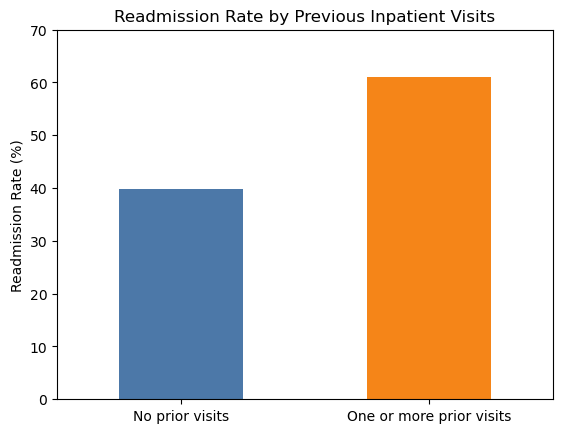

In [37]:
prior_inpatient_summary["yes"].plot(
    kind="bar",
    color=["#4C78A8", "#F58518"]
)

plt.title("Readmission Rate by Previous Inpatient Visits")
plt.xlabel("")
plt.ylabel("Readmission Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 70)
plt.show()

In [38]:
emergency_group = df_clean["n_emergency"].apply(
    lambda visits: "One or more prior visits" if visits > 0 else "No prior visits"
)

emergency_summary = pd.crosstab(
    emergency_group,
    df_clean["readmitted"],
    normalize="index"
) * 100

emergency_summary.round(1)

readmitted,no,yes
n_emergency,,
No prior visits,54.9,45.1
One or more prior visits,37.1,62.9


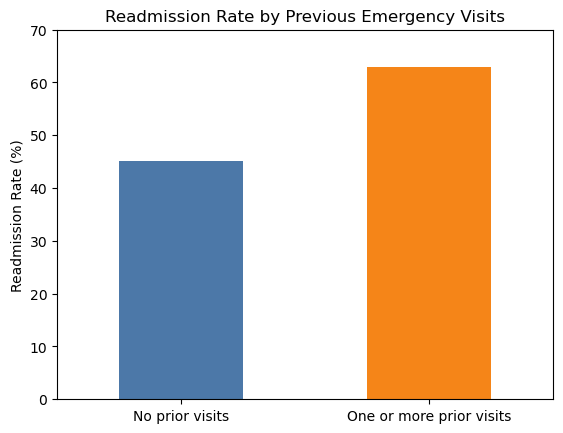

In [39]:
emergency_summary["yes"].plot(
    kind="bar",
    color=["#4C78A8", "#F58518"]
)

plt.title("Readmission Rate by Previous Emergency Visits")
plt.xlabel("")
plt.ylabel("Readmission Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 70)
plt.show()

In [40]:
outpatient_group = df_clean["n_outpatient"].apply(
    lambda visits: "One or more prior visits" if visits > 0 else "No prior visits"
)

outpatient_summary = pd.crosstab(
    outpatient_group,
    df_clean["readmitted"],
    normalize="index"
) * 100

outpatient_summary.round(1)

readmitted,no,yes
n_outpatient,,
No prior visits,55.6,44.4
One or more prior visits,39.8,60.2


In [41]:
df_clean.groupby("readmitted")[
    ["n_medications", "n_lab_procedures", "n_procedures"]
].mean().round(1)

,n_medications,n_lab_procedures,n_procedures
readmitted,,,
no,16.0,42.6,1.4
yes,16.6,43.9,1.3


In [42]:
diabetes_med_readmission = pd.crosstab(
    df_clean["diabetes_med"],
    df_clean["readmitted"],
    normalize="index"
) * 100

diabetes_med_readmission.round(1)

readmitted,no,yes
diabetes_med,,
no,58.6,41.4
yes,51.3,48.7


In [43]:
medication_change_readmission = pd.crosstab(
    df_clean["change"],
    df_clean["readmitted"],
    normalize="index"
) * 100

medication_change_readmission.round(1)

readmitted,no,yes
change,,
no,55.0,45.0
yes,50.6,49.4


## Key Findings

- Overall, 47.0% of hospital encounters in the dataset were readmitted.
- Readmission rates were slightly higher for patients aged 70–90, although the 90–100 age group was much smaller and should be interpreted cautiously.
- Patients who were readmitted had slightly longer hospital stays on average (4.6 days compared with 4.3 days).
- Previous healthcare use showed the strongest associations with readmission:
  - Patients with one or more previous inpatient visits had a 61.0% readmission rate, compared with 39.9% for patients with no previous inpatient visits.
  - Patients with one or more previous emergency visits had a 62.9% readmission rate, compared with 45.1% for patients with no previous emergency visits.
  - Patients with one or more previous outpatient visits had a 60.2% readmission rate, compared with 44.4% for patients with no previous outpatient visits.
- Patients receiving diabetes medication and patients whose medication changed during their stay also had slightly higher readmission rates.

These results show associations only and do not prove that any individual factor causes readmission.

## SQL Analysis

This section uses SQL queries to investigate patterns in hospital readmissions.

In [44]:
import sqlite3

conn = sqlite3.connect(":memory:")

df_clean.to_sql(
    "hospital_readmissions",
    conn,
    index=False,
    if_exists="replace"
)

25000

In [45]:
pd.read_sql_query("""
    SELECT
        readmitted,
        COUNT(*) AS patient_count,
        ROUND(
            COUNT(*) * 100.0 /
            (SELECT COUNT(*) FROM hospital_readmissions),
            1
        ) AS percentage
    FROM hospital_readmissions
    GROUP BY readmitted
    ORDER BY patient_count DESC;
""", conn)

,readmitted,patient_count,percentage
0,no,13246,53.0
1,yes,11754,47.0


In [46]:
pd.read_sql_query("""
    SELECT
        age,
        COUNT(*) AS patient_count,
        SUM(CASE WHEN readmitted = 'yes' THEN 1 ELSE 0 END) AS readmitted_patients,
        ROUND(
            100.0 * SUM(CASE WHEN readmitted = 'yes' THEN 1 ELSE 0 END)
            / COUNT(*),
            1
        ) AS readmission_rate
    FROM hospital_readmissions
    GROUP BY age
    ORDER BY age;
""", conn)

,age,patient_count,readmitted_patients,readmission_rate
0,[40-50),2532,1127,44.5
1,[50-60),4452,1966,44.2
2,[60-70),5913,2770,46.8
3,[70-80),6837,3336,48.8
4,[80-90),4516,2239,49.6
5,[90-100),750,316,42.1


In [47]:
pd.read_sql_query("""
    SELECT
        CASE
            WHEN n_inpatient = 0 THEN 'No prior inpatient visits'
            ELSE 'One or more prior inpatient visits'
        END AS prior_inpatient_visits,
        COUNT(*) AS patient_count,
        ROUND(
            100.0 * SUM(CASE WHEN readmitted = 'yes' THEN 1 ELSE 0 END)
            / COUNT(*),
            1
        ) AS readmission_rate
    FROM hospital_readmissions
    GROUP BY
        CASE
            WHEN n_inpatient = 0 THEN 'No prior inpatient visits'
            ELSE 'One or more prior inpatient visits'
        END
    ORDER BY patient_count DESC;
""", conn)

,prior_inpatient_visits,patient_count,readmission_rate
0,No prior inpatient visits,16537,39.9
1,One or more prior inpatient visits,8463,61.0


In [48]:
pd.read_sql_query("""
    SELECT
        n_inpatient AS previous_inpatient_visits,
        COUNT(*) AS patient_count,
        ROUND(
            100.0 * SUM(CASE WHEN readmitted = 'yes' THEN 1 ELSE 0 END)
            / COUNT(*),
            1
        ) AS readmission_rate
    FROM hospital_readmissions
    WHERE n_inpatient <= 4
    GROUP BY n_inpatient
    ORDER BY n_inpatient;
""", conn)

,previous_inpatient_visits,patient_count,readmission_rate
0,0,16537,39.9
1,1,4926,54.7
2,2,1909,64.6
3,3,833,70.3
4,4,358,76.3


### SQL Analysis Summary

SQL queries were used to calculate readmission counts and rates across patient groups.

- The dataset contains 25,000 hospital encounters, with an overall readmission rate of 47.0%.
- Readmission rates increased gradually from 44.5% among encounters in the 40–50 age group to 49.6% among encounters in the 80–90 age group. The 90–100 group had a lower rate of 42.1% and contained fewer encounters.
- Previous inpatient visits were strongly associated with readmission. The readmission rate increased from 39.9% for patients with no previous inpatient visits to 76.3% for those with four.
- These findings describe associations and do not establish causation.

# Final Visualisations

The exploratory analysis identified several patterns associated with hospital readmission.

This section presents the main findings using a smaller set of final visualisations selected for clarity and relevance to the project objective.

## Overall Readmission Outcomes

The dataset contains 25,000 hospital encounters. Of these, 11,754 resulted in readmission and 13,246 did not, giving an overall readmission rate of 47.0%.

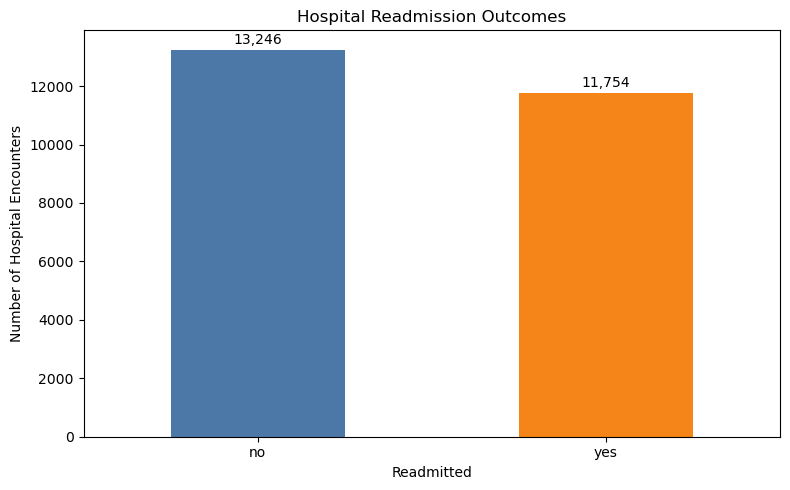

In [49]:
readmission_counts = df_clean["readmitted"].value_counts()

readmission_counts.plot(
    kind="bar",
    color=["#4C78A8", "#F58518"],
    figsize=(8, 5)
)

plt.title("Hospital Readmission Outcomes")
plt.xlabel("Readmitted")
plt.ylabel("Number of Hospital Encounters")
plt.xticks(rotation=0)

for i, value in enumerate(readmission_counts):
    plt.text(i, value + 200, f"{value:,}", ha="center")

plt.tight_layout()
plt.show()

## Readmission Rate by Age

Readmission rates were relatively similar across age groups, with a gradual increase from the 40–50 to 80–90 groups. The 90–100 group had a lower rate, but this group contained substantially fewer encounters and should therefore be interpreted cautiously.

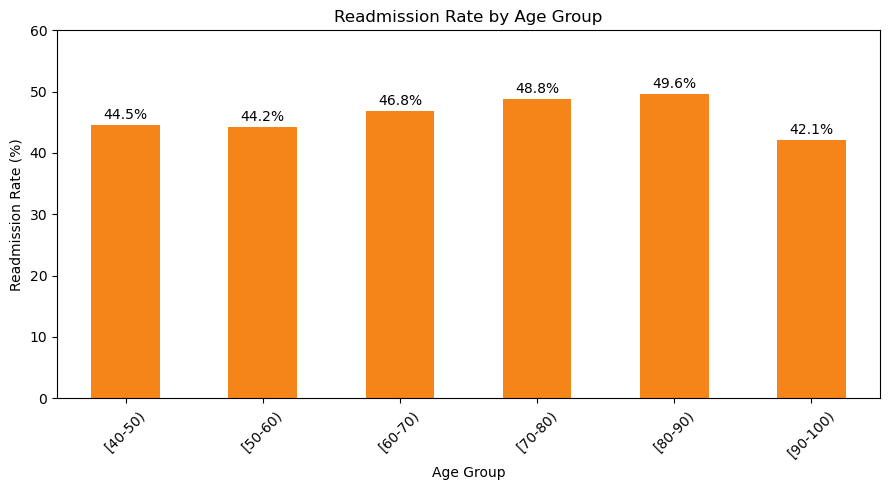

In [50]:
age_readmission["yes"].plot(
    kind="bar",
    color="#F58518",
    figsize=(9, 5)
)

plt.title("Readmission Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Readmission Rate (%)")
plt.xticks(rotation=45)
plt.ylim(0, 60)

for i, value in enumerate(age_readmission["yes"]):
    plt.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.tight_layout()
plt.show()

## Readmission Rate by Previous Inpatient Visits

Previous inpatient utilisation showed the strongest pattern identified during the analysis.

Readmission rates increased substantially as the number of previous inpatient visits increased, rising from 39.9% among encounters with no previous inpatient visits to 76.3% among encounters with four previous inpatient visits.

The number of observations becomes smaller at higher levels of previous utilisation, so the estimates for these groups should be interpreted with greater caution.

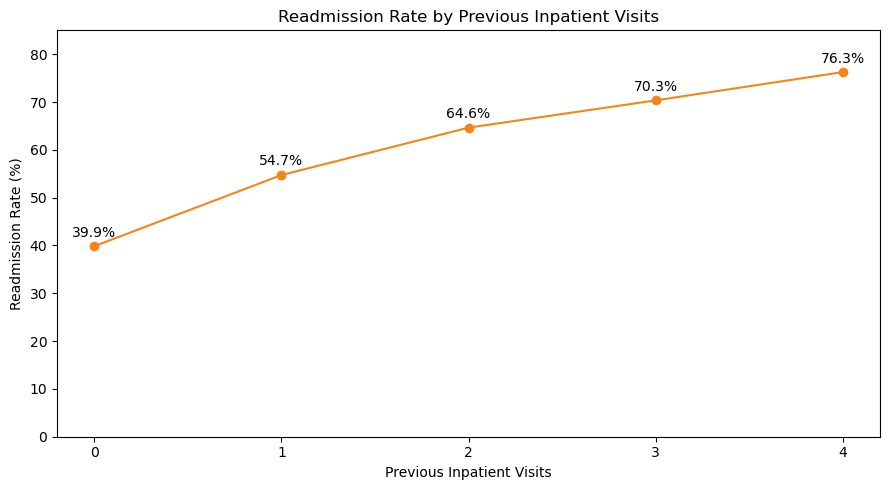

In [51]:
inpatient_final = inpatient_readmission.loc[
    inpatient_readmission.index <= 4,
    "yes"
]

inpatient_final.plot(
    kind="line",
    marker="o",
    color="#F58518",
    figsize=(9, 5)
)

plt.title("Readmission Rate by Previous Inpatient Visits")
plt.xlabel("Previous Inpatient Visits")
plt.ylabel("Readmission Rate (%)")
plt.ylim(0, 85)
plt.xticks(range(5))

for i, value in enumerate(inpatient_final):
    plt.text(i, value + 2, f"{value:.1f}%", ha="center")

plt.tight_layout()
plt.show()

## Readmission Rate by Length of Hospital Stay

Readmission rates varied across length of stay, although the relationship was less pronounced than the pattern observed for previous inpatient utilisation.

The descriptive analysis also showed that readmitted encounters had a slightly higher average length of stay than non-readmitted encounters.

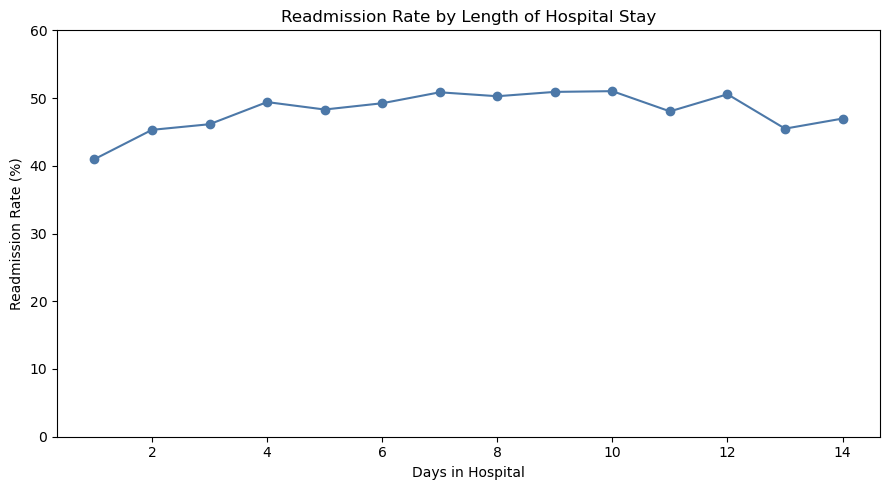

In [52]:
stay_readmission["yes"].plot(
    kind="line",
    marker="o",
    color="#4C78A8",
    figsize=(9, 5)
)

plt.title("Readmission Rate by Length of Hospital Stay")
plt.xlabel("Days in Hospital")
plt.ylabel("Readmission Rate (%)")
plt.ylim(0, 60)

plt.tight_layout()
plt.show()

## Readmission Rate by Medication Change

Encounters where diabetes medication was changed had a slightly higher readmission rate than encounters where medication was not changed.

This represents an association rather than evidence that medication changes cause readmission, as medication changes may reflect differences in patient condition or treatment needs.

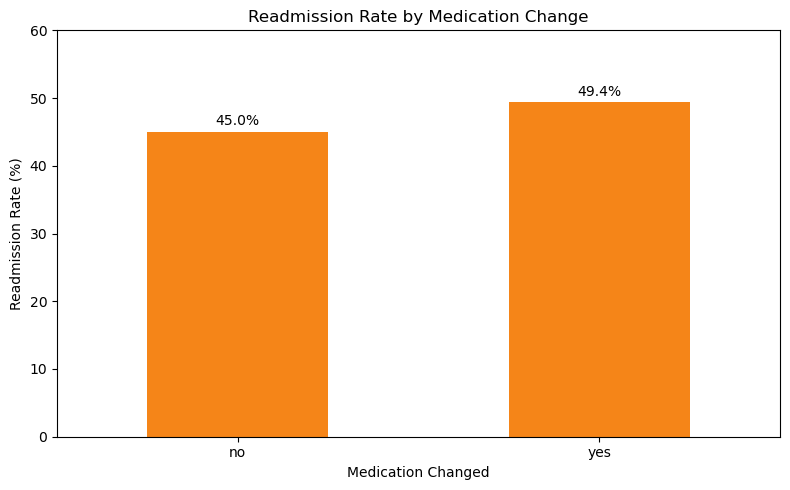

In [53]:
medication_change_readmission["yes"].plot(
    kind="bar",
    color="#F58518",
    figsize=(8, 5)
)

plt.title("Readmission Rate by Medication Change")
plt.xlabel("Medication Changed")
plt.ylabel("Readmission Rate (%)")
plt.ylim(0, 60)
plt.xticks(rotation=0)

for i, value in enumerate(medication_change_readmission["yes"]):
    plt.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.tight_layout()
plt.show()

## Visualisation Summary

The final visualisations highlight several different levels of association with readmission.

- Age showed relatively modest differences in readmission rates across groups.
- Length of hospital stay showed a weaker relationship with readmission.
- Medication changes were associated with a small increase in readmission rate.
- Previous inpatient utilisation showed the clearest relationship, with readmission rates increasing substantially as previous inpatient visits increased.

Overall, previous healthcare utilisation appears to be a more informative factor in this dataset than age alone.

# Statistical Analysis

The exploratory analysis identified several potential relationships between patient and encounter characteristics and hospital readmission.

Descriptive statistics and visualisations can highlight patterns, but they do not establish whether those patterns are statistically significant.

To investigate this further, statistical hypothesis tests will be used to assess the relationship between selected variables and readmission.

The following analyses will be performed:

- Chi-square tests for categorical variables
- A comparison of hospital length of stay between readmitted and non-readmitted encounters

A significance level of 0.05 will be used throughout the analysis.

In [54]:
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind

## Previous Inpatient Visits and Readmission

The exploratory analysis showed a substantial increase in readmission rates as the number of previous inpatient visits increased.

A chi-square test will be used to determine whether previous inpatient utilisation and readmission status are statistically associated.

In [56]:
inpatient_contingency = pd.crosstab(
    df_clean["n_inpatient"],
    df_clean["readmitted"]
)

inpatient_contingency

readmitted,no,yes
n_inpatient,,
0,9945,6592
1,2230,2696
2,675,1234
3,247,586
4,85,273
5,40,171
6,10,94
7,7,40
8,2,24


In [57]:
chi2, p_value, dof, expected = chi2_contingency(
    inpatient_contingency
)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"p-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")

Chi-square statistic: 1263.86
p-value: 0.0000
Degrees of freedom: 15


The chi-square test produced a p-value below 0.05, indicating a statistically significant association between previous inpatient utilisation and readmission status.

This supports the descriptive finding that encounters involving greater previous inpatient utilisation were more likely to result in readmission.

However, statistical association does not demonstrate that previous inpatient visits cause readmission.

## Medication Change and Readmission

The exploratory analysis showed a modest difference in readmission rates between encounters where diabetes medication was changed and encounters where it was not.

A chi-square test will be used to determine whether this difference is statistically significant.

In [58]:
medication_contingency = pd.crosstab(
    df_clean["change"],
    df_clean["readmitted"]
)

medication_contingency

readmitted,no,yes
change,,
no,7420,6077
yes,5826,5677


In [59]:
chi2, p_value, dof, expected = chi2_contingency(
    medication_contingency
)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"p-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")

Chi-square statistic: 46.51
p-value: 0.0000
Degrees of freedom: 1


## Age Group and Readmission

Readmission rates varied across age groups, although the differences appeared relatively modest compared with previous inpatient utilisation.

A chi-square test will be used to determine whether age group and readmission status are statistically associated.

In [60]:
age_contingency = pd.crosstab(
    df_clean["age"],
    df_clean["readmitted"]
)

age_contingency

readmitted,no,yes
age,,
[40-50),1405,1127
[50-60),2486,1966
[60-70),3143,2770
[70-80),3501,3336
[80-90),2277,2239
[90-100),434,316


In [61]:
chi2, p_value, dof, expected = chi2_contingency(
    age_contingency
)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"p-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")

Chi-square statistic: 48.79
p-value: 0.0000
Degrees of freedom: 5


## Length of Stay and Readmission

The descriptive analysis showed that readmitted encounters had a slightly higher average length of stay than non-readmitted encounters.

An independent samples t-test will be used to assess whether the difference in average length of stay between the two groups is statistically significant.

In [63]:
stay_readmitted = df_clean.loc[
    df_clean["readmitted"] == "yes",
    "time_in_hospital"
]

stay_not_readmitted = df_clean.loc[
    df_clean["readmitted"] == "no",
    "time_in_hospital"
]

In [64]:
t_stat, p_value = ttest_ind(
    stay_readmitted,
    stay_not_readmitted,
    equal_var=False
)

print(f"t-statistic: {t_stat:.2f}")
print(f"p-value: {p_value:.4f}")

t-statistic: 6.83
p-value: 0.0000


## Statistical Results Summary

The statistical tests provide additional evidence for interpreting the patterns identified during exploratory analysis.

The results are summarised below.

In [68]:
inpatient_chi2, inpatient_p, inpatient_dof, inpatient_expected = chi2_contingency(
    inpatient_contingency
)

In [70]:
medication_chi2, medication_p, medication_dof, medication_expected = chi2_contingency(
    medication_contingency
)

In [71]:
age_chi2, age_p, age_dof, age_expected = chi2_contingency(
    age_contingency
)

In [72]:
stay_t_stat, stay_p = ttest_ind(
    stay_readmitted,
    stay_not_readmitted,
    equal_var=False
)

In [73]:
statistical_results = pd.DataFrame({
    "Analysis": [
        "Previous inpatient visits vs readmission",
        "Medication change vs readmission",
        "Age group vs readmission",
        "Length of stay vs readmission"
    ],
    "Test": [
        "Chi-square",
        "Chi-square",
        "Chi-square",
        "Welch's t-test"
    ],
    "p_value": [
        inpatient_p,
        medication_p,
        age_p,
        stay_p
    ]
})

statistical_results

,Analysis,Test,p_value
0,Previous inpatient visits vs readmission,Chi-square,3.111453e-260
1,Medication change vs readmission,Chi-square,9.098888e-12
2,Age group vs readmission,Chi-square,2.452866e-09
3,Length of stay vs readmission,Welch's t-test,8.815237e-12


In [74]:
statistical_results["p_value"] = statistical_results["p_value"].map(
    lambda x: f"{x:.4f}"
)

statistical_results

,Analysis,Test,p_value
0,Previous inpatient visits vs readmission,Chi-square,0.0000
1,Medication change vs readmission,Chi-square,0.0000
2,Age group vs readmission,Chi-square,0.0000
3,Length of stay vs readmission,Welch's t-test,0.0000


## Statistical Findings

All four statistical tests produced p-values substantially below the 0.05 significance threshold.

This indicates statistically significant associations between:

- previous inpatient utilisation and readmission
- medication changes and readmission
- age group and readmission
- length of hospital stay and readmission

The strongest descriptive relationship observed in the analysis was between previous inpatient utilisation and readmission. Readmission rates increased substantially as the number of previous inpatient visits increased.

However, statistical significance should not be interpreted as evidence of causation. The analysis identifies associations within the dataset and does not establish that any of these factors directly cause hospital readmission.

## Practical Interpretation

Although all four statistical tests indicated statistically significant relationships, the magnitude of these relationships varied.

The relationship between previous inpatient utilisation and readmission was particularly notable. Encounters with no previous inpatient visits had a readmission rate of approximately 39.9%, compared with approximately 76.3% among encounters with four previous inpatient visits.

In contrast, the difference associated with medication changes was considerably smaller, with readmission rates of approximately 45.0% when medication was unchanged and 49.4% when medication was changed.

These differences demonstrate why statistical significance should be considered alongside the magnitude and practical relevance of an observed association.

# Conclusion

This project analysed 25,000 hospital encounters to investigate factors associated with diabetes-related hospital readmission.

The analysis combined data cleaning, exploratory data analysis, SQL querying, visualisation and statistical hypothesis testing to identify patterns within the dataset.

## Key Findings

Several factors showed statistically significant associations with readmission.

Previous inpatient utilisation demonstrated the clearest relationship. Readmission rates increased substantially as the number of previous inpatient visits increased, rising from approximately 39.9% among encounters with no previous inpatient visits to 76.3% among encounters with four previous inpatient visits.

Age was also statistically associated with readmission, although the differences between most age groups were relatively modest. Readmission rates generally increased across the 40–90 age groups before falling among the 90–100 group, which contained fewer observations.

Length of hospital stay was statistically associated with readmission, but the difference in average length of stay between readmitted and non-readmitted encounters was relatively small.

Medication changes were also statistically associated with readmission. However, the practical difference was modest, with readmission rates of approximately 45.0% when medication was unchanged compared with 49.4% when medication was changed.

Overall, previous inpatient utilisation showed the most substantial descriptive relationship with readmission among the factors examined.

## Recommendations

The findings suggest that previous inpatient utilisation could be useful when identifying encounters associated with a higher likelihood of readmission.

Healthcare teams could consider previous inpatient history as one component of a broader risk-assessment process, potentially helping to identify patients who may benefit from additional discharge planning, follow-up or support.

However, the findings should not be used to make individual clinical decisions on their own. The analysis identifies associations within the dataset rather than establishing causal relationships or providing a validated prediction model.

## Limitations

There are several limitations to this analysis.

- The dataset represents hospital encounters rather than uniquely identified patients. Therefore, multiple encounters may potentially relate to the same individual.

- The analysis is observational and identifies associations rather than causal relationships.

- Some categories contain substantially fewer observations than others. In particular, encounters with high numbers of previous inpatient visits were relatively uncommon, meaning that readmission rates for these groups should be interpreted cautiously.

- The `medical_specialty` variable contains a substantial number of missing values. These were retained during cleaning rather than removed because excluding them would have resulted in a significant loss of observations.

- Statistical significance may be influenced by the relatively large sample size. Therefore, p-values were considered alongside the magnitude and practical relevance of the observed differences.

- The analysis did not develop or validate a predictive machine-learning model, so the findings should not be interpreted as individual-level predictions of readmission.

## Future Analysis

A natural next step would be to develop a predictive model for hospital readmission.

Future work could investigate whether a combination of demographic, clinical and previous healthcare utilisation variables can improve prediction of readmission compared with individual variables alone.

Potential approaches could include logistic regression and tree-based machine learning models.

Model performance should be evaluated using appropriate metrics and validated using a separate test set or cross-validation. Particular attention would also need to be given to class imbalance, model interpretability and the potential clinical consequences of false positive and false negative predictions.

## Final Takeaway

The analysis found that previous inpatient utilisation had the strongest observed relationship with hospital readmission among the variables examined. Encounters involving greater previous inpatient utilisation had substantially higher readmission rates.

Other variables, including age, length of stay and medication changes, were also statistically associated with readmission, although the magnitude of these relationships varied.

The results suggest that previous healthcare utilisation may provide useful context when assessing readmission risk, while highlighting the importance of considering both statistical significance and practical effect size.

These findings are exploratory and should not be interpreted as evidence of causation or as a validated clinical prediction model.